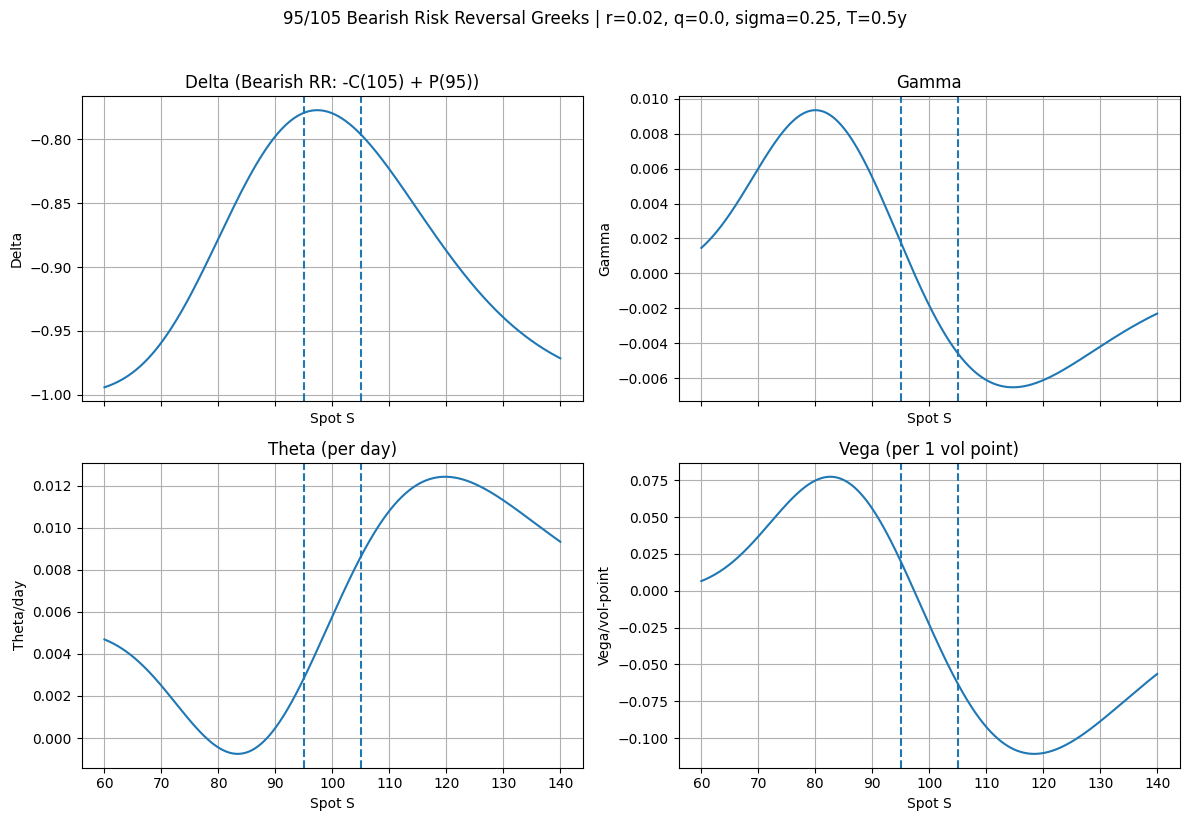

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Vectorized Normal PDF/CDF ----------
def norm_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2*np.pi)

def norm_cdf(x):
    # Abramowitz–Stegun approximation (vectorized); avoids scipy and avoids math.erf scalar issue
    x = np.asarray(x, dtype=float)
    sign = np.sign(x)
    ax = np.abs(x)

    t = 1.0 / (1.0 + 0.2316419 * ax)
    poly = t * (0.319381530 +
                t * (-0.356563782 +
                t * (1.781477937 +
                t * (-1.821255978 +
                t * 1.330274429))))
    phi = norm_pdf(ax)
    cdf_pos = 1.0 - phi * poly
    return np.where(sign >= 0, cdf_pos, 1.0 - cdf_pos)

# ---------- Black–Scholes Greeks (continuous dividend yield q) ----------
def d1_d2(S, K, r, q, sigma, T):
    S = np.asarray(S, dtype=float)
    eps = 1e-16
    T = max(float(T), eps)
    sigma = max(float(sigma), eps)

    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def bs_greeks(S, K, r, q, sigma, T, option_type="call"):
    """
    Returns (delta, gamma, theta_per_year, vega_per_1vol).
    Theta is per year. Vega is per 1.00 change in vol (divide by 100 for 1 vol point).
    """
    S = np.asarray(S, dtype=float)
    d1, d2 = d1_d2(S, K, r, q, sigma, T)

    Nd1 = norm_cdf(d1)
    Nd2 = norm_cdf(d2)
    n_d1 = norm_pdf(d1)

    disc_q = np.exp(-q * T)
    disc_r = np.exp(-r * T)

    # Delta
    if option_type.lower() == "call":
        delta = disc_q * Nd1
        theta = -(S * disc_q * n_d1 * sigma) / (2.0 * np.sqrt(T)) - r * K * disc_r * Nd2 + q * S * disc_q * Nd1
    elif option_type.lower() == "put":
        delta = disc_q * (Nd1 - 1.0)
        theta = -(S * disc_q * n_d1 * sigma) / (2.0 * np.sqrt(T)) + r * K * disc_r * norm_cdf(-d2) - q * S * disc_q * norm_cdf(-d1)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

    # Gamma (same for call/put)
    gamma = disc_q * n_d1 / (S * sigma * np.sqrt(T))

    # Vega (same for call/put)
    vega = S * disc_q * n_d1 * np.sqrt(T)

    return delta, gamma, theta, vega

# ---------- Bearish 95/105 Risk Reversal ----------
# Bearish RR convention here: -Call(105) + Put(95)
def bearish_rr_greeks(S, K_put=95.0, K_call=105.0, r=0.02, q=0.0, sigma=0.25, T=0.5):
    dC, gC, thC, vC = bs_greeks(S, K_call, r, q, sigma, T, "call")
    dP, gP, thP, vP = bs_greeks(S, K_put,  r, q, sigma, T, "put")

    delta = -dC + dP
    gamma = -gC + gP
    theta = -thC + thP
    vega  = -vC + vP
    return delta, gamma, theta, vega

# ---------- Parameters ----------
K_put  = 95.0
K_call = 105.0
r      = 0.02
q      = 0.00
sigma  = 0.25
T      = 0.5

S_grid = np.linspace(60, 140, 600)

delta, gamma, theta, vega = bearish_rr_greeks(
    S_grid, K_put=K_put, K_call=K_call, r=r, q=q, sigma=sigma, T=T
)

theta_per_day = theta / 365.0
vega_per_vol_point = vega / 100.0

# ---------- Plot ----------
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axs = axs.ravel()

axs[0].plot(S_grid, delta)
axs[0].axvline(K_put,  linestyle="--")
axs[0].axvline(K_call, linestyle="--")
axs[0].set_title("Delta (Bearish RR: -C(105) + P(95))")
axs[0].set_ylabel("Delta")

axs[1].plot(S_grid, gamma)
axs[1].axvline(K_put,  linestyle="--")
axs[1].axvline(K_call, linestyle="--")
axs[1].set_title("Gamma")
axs[1].set_ylabel("Gamma")

axs[2].plot(S_grid, theta_per_day)
axs[2].axvline(K_put,  linestyle="--")
axs[2].axvline(K_call, linestyle="--")
axs[2].set_title("Theta (per day)")
axs[2].set_ylabel("Theta/day")

axs[3].plot(S_grid, vega_per_vol_point)
axs[3].axvline(K_put,  linestyle="--")
axs[3].axvline(K_call, linestyle="--")
axs[3].set_title("Vega (per 1 vol point)")
axs[3].set_ylabel("Vega/vol-point")

for ax in axs:
    ax.grid(True)
    ax.set_xlabel("Spot S")

plt.suptitle(f"95/105 Bearish Risk Reversal Greeks | r={r}, q={q}, sigma={sigma}, T={T}y", y=1.02)
plt.tight_layout()
plt.show()


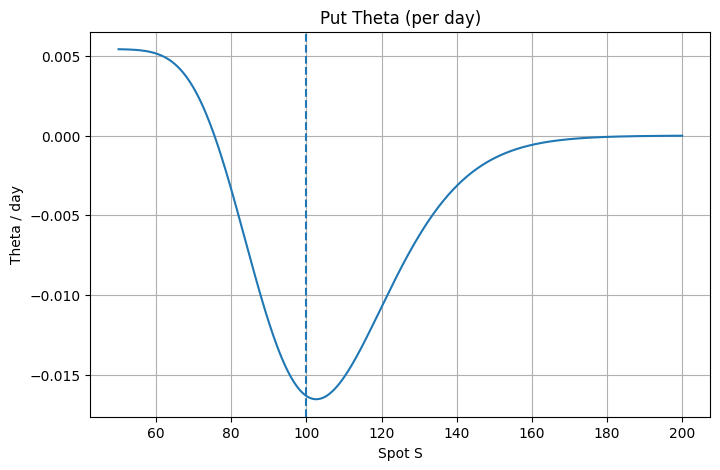

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Normal PDF / CDF (vectorized, no scipy) ----------
def norm_pdf(x):
    return np.exp(-0.5 * x**2) / np.sqrt(2*np.pi)

def norm_cdf(x):
    x = np.asarray(x)
    sign = np.sign(x)
    ax = np.abs(x)

    t = 1.0 / (1.0 + 0.2316419 * ax)
    poly = t * (0.319381530 +
                t * (-0.356563782 +
                t * (1.781477937 +
                t * (-1.821255978 +
                t * 1.330274429))))
    phi = norm_pdf(ax)
    cdf_pos = 1.0 - phi * poly
    return np.where(sign >= 0, cdf_pos, 1.0 - cdf_pos)

# ---------- Put Theta (Black–Scholes, continuous q) ----------
def put_theta(S, K, r, q, sigma, T):
    S = np.asarray(S, dtype=float)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    term_diffusion = -(S * np.exp(-q*T) * norm_pdf(d1) * sigma) / (2*np.sqrt(T))
    term_rates = r * K * np.exp(-r*T) * norm_cdf(-d2)
    term_div = -q * S * np.exp(-q*T) * norm_cdf(-d1)

    theta_year = term_diffusion + term_rates + term_div
    return theta_year / 365.0   # per day

# ---------- Parameters ----------
K     = 100.0
r     = 0.02
q     = 0.00
sigma = 0.25
T     = 0.5

S_grid = np.linspace(50, 200, 600)

theta_put = put_theta(S_grid, K, r, q, sigma, T)

# ---------- Plot ----------
plt.figure(figsize=(8, 5))
plt.plot(S_grid, theta_put)
plt.axvline(K, linestyle="--")
plt.title("Put Theta (per day)")
plt.xlabel("Spot S")
plt.ylabel("Theta / day")
plt.grid(True)
plt.show()
